In [2]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots


import itertools
import random

In [3]:
def load_cycles_from_npz(filename):
	"""
	Loads a flattened .npz file and reconstructs the nested dictionary.
	"""
	data = np.load(filename)
	reconstructed = {}
	
	for key in data.files:
		# Split the key (e.g., 'rough_foot_force')
		# We use rsplit once from the right to handle sensor names with underscores
		parts = key.split('_', 1) 
		if len(parts) < 2: continue
		
		terrain, sensor = parts[0], parts[1]
		
		if terrain not in reconstructed:
			reconstructed[terrain] = {}
		
		# Convert the (N, 100, F) array back into a list of (100, F) arrays
		# This makes it compatible with your existing segment_all_trials output
		reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
		
	print(f"Loaded {len(reconstructed)} terrains from {filename}")
	return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 3 terrains from walking_terrain_datasets.npz


In [4]:
import numpy as np

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
	"""
	Splits the gait cycle dataset into training and testing sets.
	Safely handles sensors with mismatched cycle counts.
	"""
	random.seed(seed)
	train_set = {}
	test_set = {}

	for terrain in dataset.keys():
		# 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
		# This ensures we don't try to access an index that doesn't exist for a sensor
		sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
		if not sensor_counts:
			continue
			
		min_cycles = min(sensor_counts)
		
		# 2. Generate indices based on the shortest sensor stream
		indices = list(range(min_cycles))
		random.shuffle(indices)
		
		split_idx = int(min_cycles * train_ratio)
		train_indices = indices[:split_idx]
		test_indices = indices[split_idx:]
		
		train_set[terrain] = {}
		test_set[terrain] = {}

		# 3. Distribute cycles
		for sensor in dataset[terrain].keys():
			all_cycles = dataset[terrain][sensor]
			# We only take the cycles up to min_cycles to stay synchronized
			train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
			test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
			
		print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
			  f"({len(train_indices)} train, {len(test_indices)} test)")

	return train_set, test_set


def simulate_dropped_packets(X_test, drop_rate=0.10, seed=42):
    """
    Simulates signal loss by randomly removing timesteps from each gait cycle.
    
    Parameters:
    - X_test: List of 2D numpy arrays, where each array is (timesteps, features)
    - drop_rate: Float representing the percentage of packets to drop (e.g., 0.10 for 10%)
    - seed: Random seed for reproducibility
    
    Returns:
    - X_dropped: List of degraded 2D numpy arrays.
    """
    np.random.seed(seed)
    X_dropped = []
    
    for cycle in X_test:
        num_timesteps = cycle.shape[0]
        
        # Calculate how many packets to drop and keep
        num_to_drop = int(num_timesteps * drop_rate)
        num_to_keep = num_timesteps - num_to_drop
        
        # Randomly select the indices to KEEP. 
        # We must sort them to ensure time still flows forward!
        keep_indices = np.sort(np.random.choice(num_timesteps, num_to_keep, replace=False))
        
        # Slice the array to keep only the selected timesteps
        degraded_cycle = cycle[keep_indices, :]
        X_dropped.append(degraded_cycle)
        
    return X_dropped

import numpy as np

def simulate_dropped_packets_with_zeros(X_test, drop_rate=0.10, seed=42):
    """
    Simulates signal loss by randomly overwriting entire timesteps with zeros.
    Preserves the original sequence length and structural timeline.
    
    Parameters:
    - X_test: List of 2D numpy arrays (timesteps, features)
    - drop_rate: Float representing the percentage of packets to zero out (e.g., 0.10 for 10%)
    - seed: Random seed for reproducibility
    
    Returns:
    - X_dropped: List of zero-masked 2D numpy arrays with identical original shapes.
    """
    np.random.seed(seed)
    X_dropped = []
    
    for cycle in X_test:
        num_timesteps = cycle.shape[0]
        
        # Calculate how many packet steps to turn into zeros
        num_to_drop = int(num_timesteps * drop_rate)
        
        # Randomly select which time indices will lose their signal
        drop_indices = np.random.choice(num_timesteps, num_to_drop, replace=False)
        
        # Create a deep copy so we don't accidentally corrupt the pristine data in memory
        degraded_cycle = cycle.copy()
        
        # Patch those exact positions with zero across all sensor features
        degraded_cycle[drop_indices, :] = 0.0
        
        X_dropped.append(degraded_cycle)
        
    return X_dropped

def simulate_sensor_noise(X_test, noise_level=0.10, seed=42):
    """
    Simulates electronic and mechanical sensor noise by adding channel-proportional
    Gaussian noise to the gait cycles.
    
    Parameters:
    - X_test: List of 2D numpy arrays (timesteps, features)
    - noise_level: Float representing noise intensity as a percentage of 
                   the channel's standard deviation (e.g., 0.10 for 10% noise)
    - seed: Random seed for reproducibility
    
    Returns:
    - X_noisy: List of noisy 2D numpy arrays with original shapes preserved.
    """
    np.random.seed(seed)
    X_noisy = []
    
    for cycle in X_test:
        # Create a deep copy to protect the pristine dataset in memory
        noisy_cycle = cycle.copy()
        
        # Calculate the standard deviation across time for each individual feature
        feature_stds = np.std(noisy_cycle, axis=0)
        
        # Prevent division/multiplication by zero if a sensor channel is completely flat
        feature_stds[feature_stds == 0] = 1.0
        
        # Generate standard normal noise matching the shape of the cycle
        standard_normal_noise = np.random.normal(loc=0.0, scale=1.0, size=noisy_cycle.shape)
        
        # Scale the noise: Noise = Standard_Noise * noise_level * channel_variance
        scaled_noise = standard_normal_noise * (noise_level * feature_stds)
        
        # Add the noise directly to the original signal
        noisy_cycle += scaled_noise
        X_noisy.append(noisy_cycle)
        
    return X_noisy

import numpy as np

def simulate_sensor_noise_ptp(X_test, noise_level=0.10, seed=42):
    """
    Simulates noise scaled to the Peak-to-Peak (Full-Scale) range of the sensor.
    	
    Yes, absolutely! In fact, scaling noise to the Peak-to-Peak (PTP) value or the Maximum Absolute Magnitude 
    is exactly how hardware engineers typically define the "Full-Scale Signal-to-Noise Ratio (SNR)"
    for physical sensors like load cells and ADCs.
    
    """
    np.random.seed(seed)
    X_noisy = []
    
    for cycle in X_test:
        noisy_cycle = cycle.copy()
        
        # Calculate Peak-to-Peak (Max - Min) across time for each feature
        # This is the "Full-Scale Range" of the sensor for this specific step
        
        feature_scales = np.ptp(noisy_cycle, axis=0)
        # feature_scales = np.max(np.abs(noisy_cycle), axis=0)
        
        # Fallback for completely flat signals to prevent zero-scaling
        feature_scales[feature_scales == 0] = 1.0
        
        standard_normal_noise = np.random.normal(loc=0.0, scale=1.0, size=noisy_cycle.shape)
        
        # Scale the noise by the Peak-to-Peak range
        scaled_noise = standard_normal_noise * (noise_level * feature_scales)
        
        noisy_cycle += scaled_noise
        X_noisy.append(noisy_cycle)
        
    return X_noisy

In [5]:
def format_for_esn(dataset_dict, terrain_to_id_map, sensor_order):
	"""
	Converts the nested dictionary into flat X and y lists for the ESN.
	
	dataset_dict: The output from your split_gait_dataset function.
	terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
	sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
	"""
	X_formatted = []
	y_formatted = []
	
	for terrain, sensors_data in dataset_dict.items():
		if terrain not in terrain_to_id_map:
			continue # Skip terrains we aren't training on
			
		label = terrain_to_id_map[terrain]
		
		# Get the number of cycles for this terrain (they are synchronized)
		n_cycles = len(sensors_data[sensor_order[0]])
		
		for i in range(n_cycles):
			# For cycle 'i', gather data from all 16 joints (K, D, tau)
			cycle_columns = []
			for sensor_name in sensor_order:
				# Ensure it's a numpy array
				sensor_array = np.array(sensors_data[sensor_name][i])
				
				# If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
				if len(sensor_array.shape) == 1:
					sensor_array = sensor_array.reshape(-1, 1)
					
				cycle_columns.append(sensor_array)
			
			# Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
			full_gait_matrix = np.hstack(cycle_columns)
			
			X_formatted.append(full_gait_matrix)
			y_formatted.append(label)
			
	return X_formatted, np.array(y_formatted)

In [6]:
from env_pred_1 import SupervisedESN
from env_pred_2 import HAPTRClassifier
from env_pred_3 import CNNRNNClassifier
from env_pred_4 import TCNClassifier
from env_pred_5 import SignalTransformerClassifier  

TERRAIN_LABELS = {
	'flat': 0,
	'muddy': 1,
	'water': 2
}

model_list = ["joint_kdf",
			  "leg_kdf",
			  "joint_tor",
			  "leg_grf",
			  "joint_tor_grf"]
sensor_list = [['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'],
			  ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward'],
			  ['joint_torque_fb'],
			  ['foot_force'],
			  ['joint_torque_fb', 'foot_force']]
# model_arch_list = ['esn', 'haptr', 'cnn_rnn', 'tcn', 'strn']
model_arch_list = ['esn', 'haptr', 'cnn_rnn', 'tcn']
model_arch_obj_list = {}
for model_arch in model_arch_list:
	if model_arch == 'esn':
		model_arch_obj_list[model_arch] = SupervisedESN()
	if model_arch == 'haptr':
		model_arch_obj_list[model_arch] = HAPTRClassifier()
	if model_arch == 'cnn_rnn':
		model_arch_obj_list[model_arch] = CNNRNNClassifier()
	if model_arch == 'tcn':
		model_arch_obj_list[model_arch] = TCNClassifier()
	if model_arch == 'strn':
		model_arch_obj_list[model_arch] = SignalTransformerClassifier()

In [7]:
print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=42)

Splitting dataset...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)


# Summary

In [8]:

accuracy_dict = {}

for model_arch in model_arch_list:
    # Testing drop rates from 0% to 90% in increments of 10%
    for drop_rate in np.arange(0.0, 1.00, 0.10):
        print(f"\n--- Model: {model_arch.upper()} | Drop Rate: {drop_rate*100:.0f}% ---")
        print("Formatting data ...")

        X_train, y_train = format_for_esn(train_data, TERRAIN_LABELS, ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'])
        X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'])

        # Apply the in-place zero-masking drop simulation
        X_test = simulate_dropped_packets_with_zeros(X_test, drop_rate=drop_rate, seed=100)

        print("Booting up Controller...")
        if model_arch == 'esn':
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.npz")
        else:
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.pt")

        print("Evaluating on unseen Test Set...")
        y_pred = []

        # Collect all predictions
        for i in range(len(X_test)):
            input_sample = X_test[i]
            
            # Cleaner loop: No padding conditions or checks required anymore!
            predicted_class, confidence = model_arch_obj_list[model_arch].predict(input_sample)
            y_pred.append(predicted_class)

        # Convert to numpy array for fast comparison
        y_pred = np.array(y_pred)

        # Calculate Accuracy
        correct = np.sum(y_pred == y_test)
        accuracy = (correct / len(X_test)) * 100
        print(f"-> Test Accuracy: {accuracy:.2f}%")

        # Map to proper display names for your final dictionary
        model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'

        if model_arch_name not in accuracy_dict:
            accuracy_dict[model_arch_name] = {}

        # Save the result
        accuracy_dict[model_arch_name][f"{drop_rate*100:.0f}%"] = accuracy


--- Model: ESN | Drop Rate: 0% ---
Formatting data ...
Booting up Controller...

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------

Evaluating on unseen Test Set...
-> Test Accuracy: 94.32%

--- Model: ESN | Drop Rate: 10% ---
Formatting data ...
Booting up Controller...

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
-

In [9]:
print("\nFinal Accuracy Comparison:", accuracy_dict)


Final Accuracy Comparison: {'ESN': {'0%': 94.31818181818183, '10%': 94.31818181818183, '20%': 89.77272727272727, '30%': 89.77272727272727, '40%': 89.77272727272727, '50%': 87.5, '60%': 90.9090909090909, '70%': 88.63636363636364, '80%': 87.5, '90%': 85.22727272727273}, 'HAPTR': {'0%': 98.86363636363636, '10%': 93.18181818181817, '20%': 87.5, '30%': 72.72727272727273, '40%': 60.22727272727273, '50%': 51.13636363636363, '60%': 36.36363636363637, '70%': 30.681818181818183, '80%': 30.681818181818183, '90%': 30.681818181818183}, 'CNN-RNN': {'0%': 95.45454545454545, '10%': 94.31818181818183, '20%': 93.18181818181817, '30%': 87.5, '40%': 81.81818181818183, '50%': 76.13636363636364, '60%': 75.0, '70%': 71.5909090909091, '80%': 67.04545454545455, '90%': 54.54545454545454}, 'TCN': {'0%': 97.72727272727273, '10%': 97.72727272727273, '20%': 97.72727272727273, '30%': 97.72727272727273, '40%': 95.45454545454545, '50%': 93.18181818181817, '60%': 86.36363636363636, '70%': 78.4090909090909, '80%': 68.1


Generating Temporal Robustness Chart...


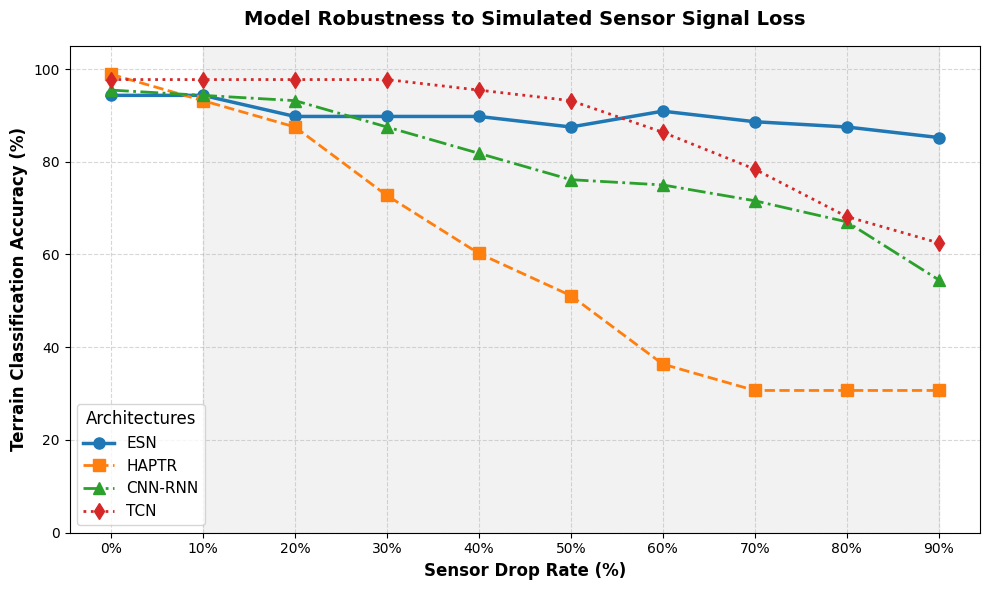

[SUCCESS] Robustness plot saved as 'dropped_packet_robustness.png'


In [10]:
import matplotlib.pyplot as plt

# --- 7. Plotting the Degradation Curve ---
print("\nGenerating Temporal Robustness Chart...")

plt.figure(figsize=(10, 6))

# Define clean styles to match top-tier academic journals (ICRA/IROS)
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linewidth': 2.5, 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's', 'linewidth': 2, 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^', 'linewidth': 2, 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'd', 'linewidth': 2, 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'v', 'linewidth': 2, 'linestyle': '--'}
}

# Extract the drop rates from the inner dictionary keys dynamically
# e.g., ['5% Drop Rate', '10% Drop Rate', '20% Drop Rate', '50% Drop Rate']
drop_labels = list(next(iter(accuracy_dict.values())).keys())

for model_name, drops in accuracy_dict.items():
    # Fetch accuracies in order matching the drop labels
    accuracies = [drops[label] for label in drop_labels]
    
    # Get the designated visual style if defined, otherwise fallback to defaults
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linewidth': 2, 'linestyle': '-'})
    
    plt.plot(drop_labels, accuracies, label=model_name,
             color=style['color'],
             marker=style['marker'],
             linewidth=style['linewidth'],
             linestyle=style['linestyle'],
             markersize=8)

# Aesthetics and annotations
plt.title('Model Robustness to Simulated Sensor Signal Loss', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sensor Drop Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Terrain Classification Accuracy (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Architectures', fontsize=11, title_fontsize=12, loc='lower left')

# Shading the region where the continuous state integration dominates
plt.axvspan(drop_labels[1], drop_labels[-1], color='gray', alpha=0.1, label='ESN Dominance Zone')

plt.tight_layout()

# Save image file directly
# plt.savefig('dropped_packet_robustness.png', dpi=300)
plt.show()

print("[SUCCESS] Robustness plot saved as 'dropped_packet_robustness.png'")

# Test Dropouts

In [11]:
import numpy as np

# Define a list of different seeds to test the statistical variance
seeds = [42, 100, 2023, 777, 999, 1234, 2024, 5555, 8888, 4321] 
drop_rates = np.arange(0.0, 1.00, 0.10)

# Final dictionary to hold the statistical results
accuracy_stats = {}

for model_arch in model_arch_list:
    model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'
    accuracy_stats[model_arch_name] = {}
    
    print(f"\n=========================================")
    print(f"STARTING MULTI-SEED BENCHMARK FOR: {model_arch_name}")
    print(f"=========================================")

    # Boot up the model once outside the loop to save time
    if model_arch == 'esn':
        model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.npz")
    else:
        model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.pt")

    for drop_rate in drop_rates:
        drop_percentage_str = f"{drop_rate*100:.0f}%"
        seed_accuracies = []
        
        print(f"\nEvaluating {drop_percentage_str} drop rate across {len(seeds)} seeds...")
        
        for seed in seeds:
            # 1. Format clean data copies
            X_train, y_train = format_for_esn(train_data, TERRAIN_LABELS, ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'])
            X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'])

            # 2. Apply dropout using the CURRENT seed
            X_test_degraded = simulate_dropped_packets_with_zeros(X_test, drop_rate=drop_rate, seed=seed)

            # 3. Predict loop
            y_pred = []
            for i in range(len(X_test_degraded)):
                predicted_class, _ = model_arch_obj_list[model_arch].predict(X_test_degraded[i])
                y_pred.append(predicted_class)

            y_pred = np.array(y_pred)
            correct = np.sum(y_pred == y_test)
            accuracy = (correct / len(X_test_degraded)) * 100
            
            seed_accuracies.append(accuracy)
            
        # --- 4. STATISTICAL CALCULATIONS ---
        mean_accuracy = np.mean(seed_accuracies)
        std_accuracy = np.std(seed_accuracies)
        
        print(f"-> Result for {drop_percentage_str}: Mean = {mean_accuracy:.2f}%, Std = {std_accuracy:.2f}%")
        
        # Save both values into our dictionary
        accuracy_stats[model_arch_name][drop_percentage_str] = {
            'mean': mean_accuracy,
            'std': std_accuracy
        }


STARTING MULTI-SEED BENCHMARK FOR: ESN

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------


Evaluating 0% drop rate across 10 seeds...
-> Result for 0%: Mean = 94.32%, Std = 0.00%

Evaluating 10% drop rate across 10 seeds...
-> Result for 10%: Mean = 92.39%, Std = 1.53%

Evaluating 20% drop rate across 10 seeds...
-> Result for 20%: Mean = 92.16%, Std = 1.64%

Evaluating 30% drop rate across 10 seeds...
-> Result for 30%: Mean = 91.70%, Std = 1.53%

Evaluating 40% drop rate across 10 seeds...
-> Result for 40%: Mean = 91.59%, Std = 1.04%

Evaluating 50% drop rate across 10 seeds...
-> Result for 50%: Mean = 91.48%, Std = 1.70%

Evalu

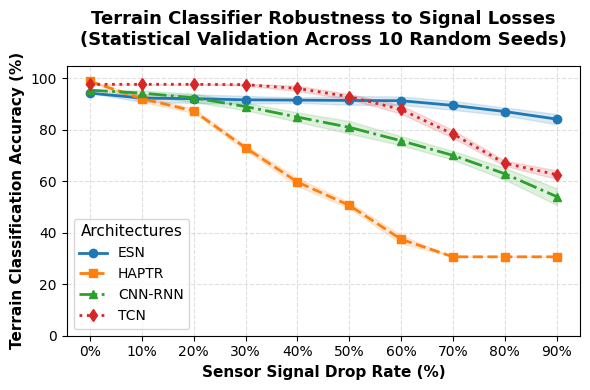

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Clean journal-ready styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'd', 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'v', 'linestyle': '--'}
}

# Extract strings for x-axis ticks
drop_labels = [f"{dr*100:.0f}%" for dr in drop_rates]

for model_name, drop_data in accuracy_stats.items():
    # Extract means and stds sequentially matching the drop rates
    means = np.array([drop_data[label]['mean'] for label in drop_labels])
    stds = np.array([drop_data[label]['std'] for label in drop_labels])
    
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linestyle': '-'})
    
    # 1. Plot the mean line
    plt.plot(drop_labels, means, label=model_name,
             color=style['color'], marker=style['marker'], 
             linestyle=style['linestyle'], linewidth=2, markersize=6)
    
    # 2. Plot the shaded standard deviation area (1 Std Dev above and below the mean)
    plt.fill_between(drop_labels, means - stds, means + stds, 
                     color=style['color'], alpha=0.15)

plt.title('Terrain Classifier Robustness to Signal Losses\n(Statistical Validation Across 10 Random Seeds)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Sensor Signal Drop Rate (%)', fontsize=11, fontweight='bold')
plt.ylabel('Terrain Classification Accuracy (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Architectures', fontsize=10, title_fontsize=11, loc='lower left')

plt.tight_layout()
plt.savefig('dropped_packet_robustness.png', dpi=300)
plt.show()

# Test Noise

In [13]:
# Testing noise levels from 0% to 90%
noise_levels = np.arange(0.0, 1.00, 0.10)
seeds = [42, 100, 2023, 777, 999]

noise_stats = {}

for model_arch in model_arch_list:
    model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'
    noise_stats[model_arch_name] = {}
    
    # Load model once
    if model_arch == 'esn':
        model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.npz")
    else:
        model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_joint_kdf.pt")

    for level in noise_levels:
        level_str = f"{level*100:.0f}% Noise"
        seed_accuracies = []
        
        for seed in seeds:
            # Format clean data
            _, _ = format_for_esn(train_data, TERRAIN_LABELS, ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'])
            X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'])

            # APPLY SENSOR NOISE SIMULATION
            X_test_noisy = simulate_sensor_noise_ptp(X_test, noise_level=level, seed=seed)

            # Predict
            y_pred = []
            for i in range(len(X_test_noisy)):
                predicted_class, _ = model_arch_obj_list[model_arch].predict(X_test_noisy[i])
                y_pred.append(predicted_class)

            correct = np.sum(np.array(y_pred) == y_test)
            seed_accuracies.append((correct / len(X_test_noisy)) * 100)
            
        noise_stats[model_arch_name][level_str] = {
            'mean': np.mean(seed_accuracies),
            'std': np.std(seed_accuracies)
        }
        print(f"[{model_arch_name}] {level_str} -> Mean Accuracy: {np.mean(seed_accuracies):.2f}%")


[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------

[ESN] 0% Noise -> Mean Accuracy: 94.32%
[ESN] 10% Noise -> Mean Accuracy: 91.82%
[ESN] 20% Noise -> Mean Accuracy: 90.91%
[ESN] 30% Noise -> Mean Accuracy: 90.45%
[ESN] 40% Noise -> Mean Accuracy: 88.41%
[ESN] 50% Noise -> Mean Accuracy: 85.68%
[ESN] 60% Noise -> Mean Accuracy: 83.86%
[ESN] 70% Noise -> Mean Accuracy: 81.59%
[ESN] 80% Noise -> Mean Accuracy: 80.00%
[ESN] 90% Noise -> Mean Accuracy: 77.50%

[SUCCESS] HAPTR Model loaded from: 'model_haptr/env_pred_haptr_best_joint_kdf.pt'
----------------------------------------
💡 Hyperparameters:
   • Variant:        Large (Layers: 8,

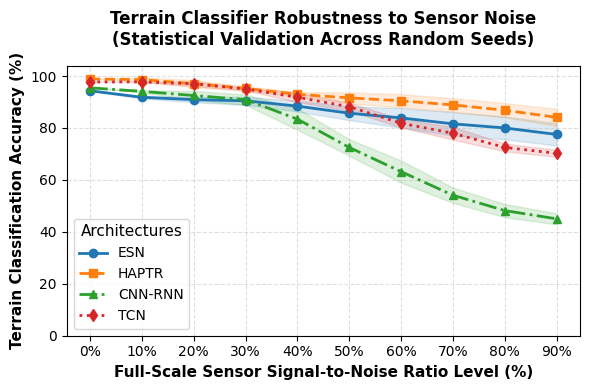

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Clean journal-ready styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'd', 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'v', 'linestyle': '--'}
}

# Generate noise levels matching your evaluation loop (0.0 to 0.9)
noise_levels = np.arange(0.0, 1.00, 0.10)

# Match the exact string keys inside your noise_stats dictionary
data_keys = [f"{nl*100:.0f}% Noise" for nl in noise_levels]

# Clean percentage strings to display on the X-axis ticks
display_labels = [f"{nl*100:.0f}%" for nl in noise_levels]

for model_name, noise_data in noise_stats.items():
    # Safely extract means and stds sequentially using the exact dictionary keys
    means = np.array([noise_data[key]['mean'] for key in data_keys])
    stds = np.array([noise_data[key]['std'] for key in data_keys])
    
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linestyle': '-'})
    
    # 1. Plot the mean line against the display labels
    plt.plot(display_labels, means, label=model_name,
             color=style['color'], marker=style['marker'], 
             linestyle=style['linestyle'], linewidth=2, markersize=6)
    
    # 2. Plot the shaded standard deviation area (1 Std Dev above and below the mean)
    plt.fill_between(display_labels, means - stds, means + stds, 
                     color=style['color'], alpha=0.15)

plt.title('Terrain Classifier Robustness to Sensor Noise\n(Statistical Validation Across Random Seeds)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Full-Scale Sensor Signal-to-Noise Ratio Level (%)', fontsize=11, fontweight='bold')
plt.ylabel('Terrain Classification Accuracy (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 104)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Architectures', fontsize=10, title_fontsize=11, loc='lower left')

plt.tight_layout()
plt.savefig('sensor_noise_robustness.png', dpi=300)
plt.show()

# Combine plots

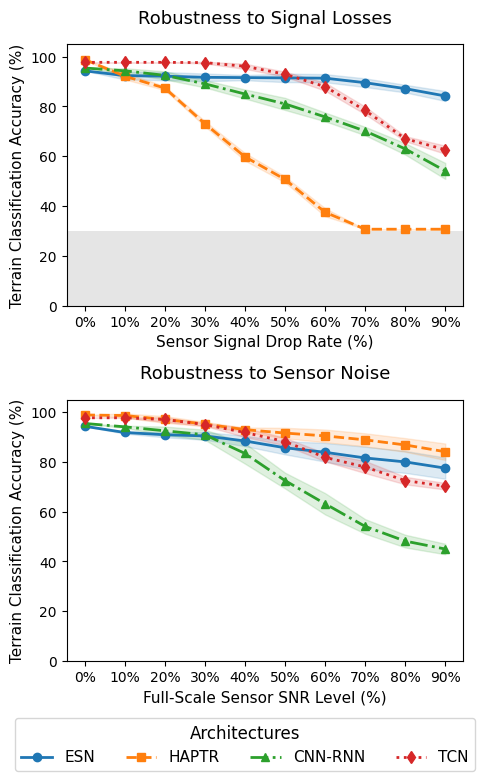

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a figure with 2 rows and 1 column
fig, axes = plt.subplots(2, 1, figsize=(5, 8))

# Clean journal-ready styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'd', 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'v', 'linestyle': '--'}
}


# ==========================================
# Subplot 1 (Top): Signal Losses
# ==========================================
ax1 = axes[0]
drop_labels = [f"{dr*100:.0f}%" for dr in drop_rates]

for model_name, drop_data in accuracy_stats.items():
    means = np.array([drop_data[label]['mean'] for label in drop_labels])
    stds = np.array([drop_data[label]['std'] for label in drop_labels])
    
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linestyle': '-'})
    
    ax1.plot(drop_labels, means, label=model_name,
             color=style['color'], marker=style['marker'], 
             linestyle=style['linestyle'], linewidth=2, markersize=6)
    
    ax1.fill_between(drop_labels, means - stds, means + stds, 
                     color=style['color'], alpha=0.15)

# NEW: Add grey horizontal span for 0-30% accuracy
ax1.axhspan(0, 30, facecolor='gray', alpha=0.2, zorder=0)

ax1.set_title('Robustness to Signal Losses', fontsize=13, pad=15)
ax1.set_xlabel('Sensor Signal Drop Rate (%)', fontsize=11)
ax1.set_ylabel('Terrain Classification Accuracy (%)', fontsize=11)
ax1.set_ylim(0, 105)


# ==========================================
# Subplot 2 (Bottom): Sensor Noise
# ==========================================
ax2 = axes[1]
noise_levels = np.arange(0.0, 1.00, 0.10)
data_keys = [f"{nl*100:.0f}% Noise" for nl in noise_levels]
display_labels = [f"{nl*100:.0f}%" for nl in noise_levels]

for model_name, noise_data in noise_stats.items():
    means = np.array([noise_data[key]['mean'] for key in data_keys])
    stds = np.array([noise_data[key]['std'] for key in data_keys])
    
    style = styles.get(model_name, {'color': None, 'marker': 'o', 'linestyle': '-'})
    
    ax2.plot(display_labels, means, label=model_name,
             color=style['color'], marker=style['marker'], 
             linestyle=style['linestyle'], linewidth=2, markersize=6)
    
    ax2.fill_between(display_labels, means - stds, means + stds, 
                     color=style['color'], alpha=0.15)

# NEW: Add grey horizontal span for 0-30% accuracy
# ax2.axhspan(0, 30, facecolor='gray', alpha=0.2, zorder=0)

ax2.set_title('Robustness to Sensor Noise', fontsize=13, pad=15)
ax2.set_xlabel('Full-Scale Sensor SNR Level (%)', fontsize=11)
ax2.set_ylabel('Terrain Classification Accuracy (%)', fontsize=11)
ax2.set_ylim(0, 105) 
ax2.legend(title='Architectures', fontsize=11, title_fontsize=12, loc='lower center', ncol=4, bbox_to_anchor=(0.45, -0.45))


# ==========================================
# Final Figure Adjustments
# ==========================================
plt.tight_layout()

# Save and show
plt.savefig('combined_robustness.png', dpi=500)
plt.show()